<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 158 &middot; Data Ethics, Bias &amp; Fairness &middot; Notebook 2 of 2</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">The Fairness-Accuracy Tradeoff</div>
  <div style="font-size:15px;color:#ffe4e6;max-width:760px;line-height:1.6">You cannot maximize every fairness metric at once, or fairness and accuracy together. This notebook forces demographic parity on the model and measures exactly what it costs, then shows why 'which fairness?' is a value choice, not a calculation.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
ROSE, BL, GR, RD, MUT = "#be123c", "#2563eb", "#16a34a", "#dc2626", "#94a3b8"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "data-ethics--lending.xlsx"
try: df = pd.read_excel("../../data/" + fn, sheet_name="applicants")
except FileNotFoundError: df = pd.read_excel(BASE + fn, sheet_name="applicants")
# NOTE: the protected attribute 'group' is deliberately NOT a model input ("fairness through unawareness").
FEAT = ["income_k", "debt_to_income", "credit_history_years", "prior_defaults"]
Xtr, Xte, ytr, yte, gtr, gte = train_test_split(df[FEAT], df.repaid, df.group, test_size=0.4, random_state=1, stratify=df.group)
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
te = pd.DataFrame({"group": gte.values, "repaid": yte.values, "p": clf.predict_proba(Xte)[:,1]})
te["approved"] = (te.p >= 0.5).astype(int)
A, Bg = te[te.group=="A"], te[te.group=="B"]
print("test set:", len(te), "| group A", len(A), "| group B", len(Bg))

test set: 1600 | group A 1089 | group B 511


## Step 1 &middot; Where we start
Recall the unfair baseline: the model approves group A at a much higher rate than group B, even though it is well-calibrated for both. Suppose we decide demographic parity is what we care about, equal approval rates. We can force it by using a different decision threshold for each group.

In [2]:
sel_A = A.approved.mean()
print(f"baseline approval  A {sel_A:.1%}   B {Bg.approved.mean():.1%}   (unequal)")
# lower the threshold for group B until its approval rate matches A's
thr_B = np.quantile(Bg.p, 1 - sel_A)
Bg = Bg.assign(approved_fair=(Bg.p >= thr_B).astype(int))
print(f"\ngroup-B threshold lowered from 0.50 to {thr_B:.2f}")
print(f"group-B approval rate  {Bg.approved.mean():.1%}  ->  {Bg.approved_fair.mean():.1%}  (now matches A)")

baseline approval  A 73.5%   B 27.0%   (unequal)

group-B threshold lowered from 0.50 to 0.32
group-B approval rate  27.0%  ->  73.4%  (now matches A)


## Step 2 &middot; What parity costs
Equalizing the approval rate is not free. Because group B has a lower true repayment rate, approving more of them means approving more who will not repay. Accuracy falls, and the model is now over-approving group B relative to its actual creditworthiness, so its honest calibration is broken on purpose.

In [3]:
acc_before = (Bg.approved == Bg.repaid).mean()
acc_after  = (Bg.approved_fair == Bg.repaid).mean()
tpr_before = Bg[Bg.repaid==1].approved.mean()
tpr_after  = Bg[Bg.repaid==1].approved_fair.mean()
print(f"group-B accuracy   {acc_before:.1%}  ->  {acc_after:.1%}   (parity costs accuracy)")
print(f"group-B true positive rate  {tpr_before:.1%}  ->  {tpr_after:.1%}   (more deserving applicants approved)")
print(f"group-B approvals who will NOT repay: {(Bg.approved_fair[Bg.repaid==0]).mean():.1%} of defaulters now approved")

group-B accuracy   65.9%  ->  55.2%   (parity costs accuracy)
group-B true positive rate  41.1%  ->  86.1%   (more deserving applicants approved)
group-B approvals who will NOT repay: 65.0% of defaulters now approved


## Step 3 &middot; The impossibility, made concrete
You cannot have it all. With different base rates between groups, demographic parity, equal error rates, and calibration cannot hold at once, this is a proven mathematical result, not a modeling shortcoming. The table shows the two ends: keep calibration (the baseline) or force parity, but not both.

In [4]:
rows = []
rows.append(["Calibrated model (baseline)", f"{A.approved.mean():.0%} / {Bg.approved.mean():.0%}",
             "yes", f"{(Bg.approved==Bg.repaid).mean():.0%}"])
rows.append(["Forced demographic parity",  f"{A.approved.mean():.0%} / {Bg.approved_fair.mean():.0%}",
             "no",  f"{(Bg.approved_fair==Bg.repaid).mean():.0%}"])
print(pd.DataFrame(rows, columns=["Policy","Approval A / B","Calibrated?","B accuracy"]).to_string(index=False))
print("\nNeither row is 'the fair one'. Choosing between them is a value judgment about which harm matters more.")

                     Policy Approval A / B Calibrated? B accuracy
Calibrated model (baseline)      73% / 27%         yes        66%
  Forced demographic parity      73% / 73%          no        55%

Neither row is 'the fair one'. Choosing between them is a value judgment about which harm matters more.


## Step 4 &middot; The tradeoff curve
Sweep the group-B threshold from strict to lenient and watch accuracy and the approval-rate gap move in opposite directions. There is no single best point; where you stand depends on what you are optimizing and who bears the cost of each error.

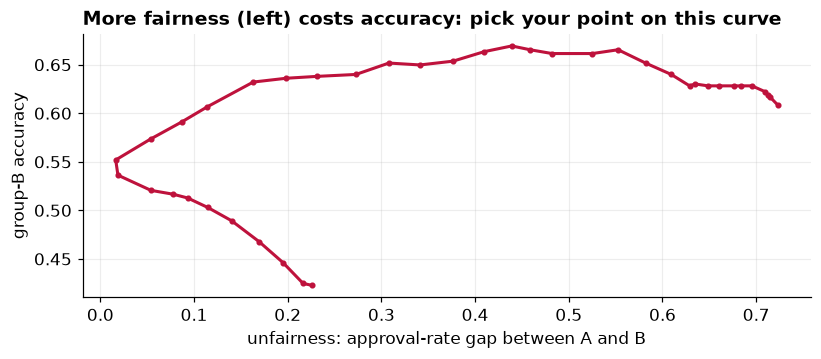

Left = fairer (smaller gap) but lower accuracy. Right = more accurate but less equal. The curve is the tradeoff.


In [5]:
ths = np.linspace(0.2, 0.7, 40)
gap, acc = [], []
for t in ths:
    apr = (Bg.p >= t).astype(int)
    gap.append(abs(A.approved.mean() - apr.mean()))
    acc.append((apr == Bg.repaid).mean())
fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.plot(gap, acc, color=ROSE, lw=2, marker="o", ms=3)
ax.set_xlabel("unfairness: approval-rate gap between A and B"); ax.set_ylabel("group-B accuracy")
ax.set_title("More fairness (left) costs accuracy: pick your point on this curve")
plt.tight_layout(); plt.show()
print("Left = fairer (smaller gap) but lower accuracy. Right = more accurate but less equal. The curve is the tradeoff.")

### Wrap-up
Forcing equal approval rates cut group-B accuracy and broke the model's calibration, and it had to, because the groups differ in base rate. The lesson is not that fairness is impossible but that 'fair' is not one thing: demographic parity, equal opportunity, and calibration are different goals that trade off against each other and against accuracy. Which one to honor is a decision for humans, made in the open, not a number the model computes for you.